# Figure 4 — GARW variant growth-rate inference (representative run)

Rebuilt for run 14 (`nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75`). Panel A: log(MAE) of
GARW variant growth-rate by deme, with the example windows' variants circled. Panels B-E: the
example windows (B a low-error success, C-E high-error). Writes to `reviews/round1/figures/`.
Run with the repo root on the path (the `sys.path` shim handles the VSCode kernel).


In [1]:
import sys
sys.path.append("..")  # repo root on path so antigentools imports under any kernel (VSCode).

import glob
import json
import random
from typing import Optional, List, Dict, Any

import pandas as pd
import numpy as np
import evofr as ef
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import seaborn as sns

from antigentools.utils import get_deme_stats, get_outliers
from antigentools.analysis import get_filtered_growth_rates_df, filter_growth_rates
from antigentools.plot import (
    plot_analysis_window_with_variant_counts,
    plot_growth_rate_dynamics,
    plot_observed_cases,
    get_analysis_window,
    print_window_stats,
)
from antigentools.publication_style import (
    apply_publication_styling_to_figure,
    style_figure_for_publication,
    PublicationFigureStyler,
    publication_style,
)

# Growth-rate filtering constants (match fig-4).
CONNECT_GAPS = True
MIN_SEGMENT_LENGTH = 3
MIN_SEQUENCE_COUNT = 10
MIN_VARIANT_FREQUENCY = 0.01
MIN_VARIANT_INCIDENCE = 50.0
EPSILON = 1e-3
MIN_TOTAL_SEQUENCES = 300
CONVERGENCE_THRESHOLD = 0.5

# Representative run (run 14). Data + scp'd estimates staged at the batch root, so `build`
# resolves both ../data/<build>/ and ../results/<build>/estimates/. flu-final is in git history.
build = "2026-07-04-reviewer-runs"
print(f"Analysis configuration for build: {build}")

# Same shared convention as the supplement figures, scaled to this
# figure's canvas. This shares plot_combined_growth_rate_figure with
# figure S6 (the function is duplicated in both notebooks), so the two
# must be kept in step by hand.
from antigentools.supplement_style import scale_for_canvas

FIG4_CANVAS_WIDTH_IN = 30.0
FIG4_SIZES = scale_for_canvas(FIG4_CANVAS_WIDTH_IN)


/Users/zo/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analysis configuration for build: 2026-07-04-reviewer-runs


In [2]:
# Load truth data.
truth_set_dir = f"../data/{build}/time-stamped/truth/"
truth_seqs_df = pd.read_csv(f"{truth_set_dir}/seq_counts.tsv", sep="\t")
truth_cases_df = pd.read_csv(f"{truth_set_dir}/case_counts.tsv", sep="\t")

# Run 14's results are nested (not flattened like its data), so read the errors file by its
# explicit per-run path.
variant_growth_rates_scores_path = "../results/2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75__run_14/variant_growth_rates.tsv"
variant_growth_rate_errors_all = pd.read_csv(variant_growth_rates_scores_path, sep="\t")
variant_growth_rate_errors_all["log_mae"] = np.log(variant_growth_rate_errors_all["mae"] + 1e-6)
variant_growth_rate_errors_all["log_mse"] = np.log(variant_growth_rate_errors_all["mse"] + 1e-6)

# Converged-only view drives the boxplot distribution (matches the GARW figure). The full view
# (`..._all`) is used by the FGA figure to force-circle a deliberately-included non-converged window.
variant_growth_rate_errors_df = variant_growth_rate_errors_all[variant_growth_rate_errors_all["converged"] == True]
print(f"Error rows: {len(variant_growth_rate_errors_all)} total, {len(variant_growth_rate_errors_df)} converged")


Error rows: 464 total, 235 converged


In [3]:
# Deme palette.
deme_palette = {
    "tropics": "#3498db",
    "north": "#e67e22",
    "south": "#2ecc71",
}

# Variant color map: use the saved auspice map if present, else derive one from the run's tips
# (run 14 has no per-run auspice map). Panels index color_map[v_name] directly and v_name may be
# int or str, so key the map on both forms.
import os
import matplotlib.colors as mcolors


def create_variant_color_map(tips_df, variant_col="variant_ag", time_col="year"):
    order = tips_df.groupby(variant_col)[time_col].min().sort_values().index.tolist()
    golden = 0.618033988749895
    colors = []
    for i in range(len(order)):
        hue = (i * golden) % 1.0
        sat, val = [(0.9, 0.95), (0.7, 0.85), (0.85, 0.75)][i % 3]
        colors.append(mcolors.rgb2hex(mcolors.hsv_to_rgb([hue, sat, val])))
    return {v: colors[i] for i, v in enumerate(order)}


color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
if os.path.exists(color_map_path):
    color_map_df = pd.read_csv(color_map_path, sep="\t")
    _cm = dict(zip(color_map_df["TRAIT_VALUE"], color_map_df["HEX_CODE"]))
else:
    _tips = pd.read_csv(f"../data/{build}/tips_with_variants.tsv", sep="\t")
    _cm = create_variant_color_map(_tips, "variant_ag", "year")

color_map = {}
for k, v in _cm.items():
    color_map[int(k)] = v
    color_map[str(k)] = v
color_map_str = {str(k): v for k, v in _cm.items()}
print(f"Created color map with {len(_cm)} variants")


Created color map with 30 variants


In [4]:
# The zoom-in panels and the figure driver live in antigentools now. They were
# defined identically here, in manuscript-figure-S6, and in variant-zoom-in-finder,
# and generated into two of those by a script -- so keeping them in step by hand had
# already failed (a title had to be removed twice; a font change reached S6 but not
# this figure). Font sizes and the variant-inclusion thresholds are module defaults
# there, matching what this cell used to set locally.
from antigentools.growth_rate_panels import plot_combined_growth_rate_figure


Saved ../../antigen-tex/reviews/round1/figures/figure4_combined_growth_rate_figure_garw.pdf


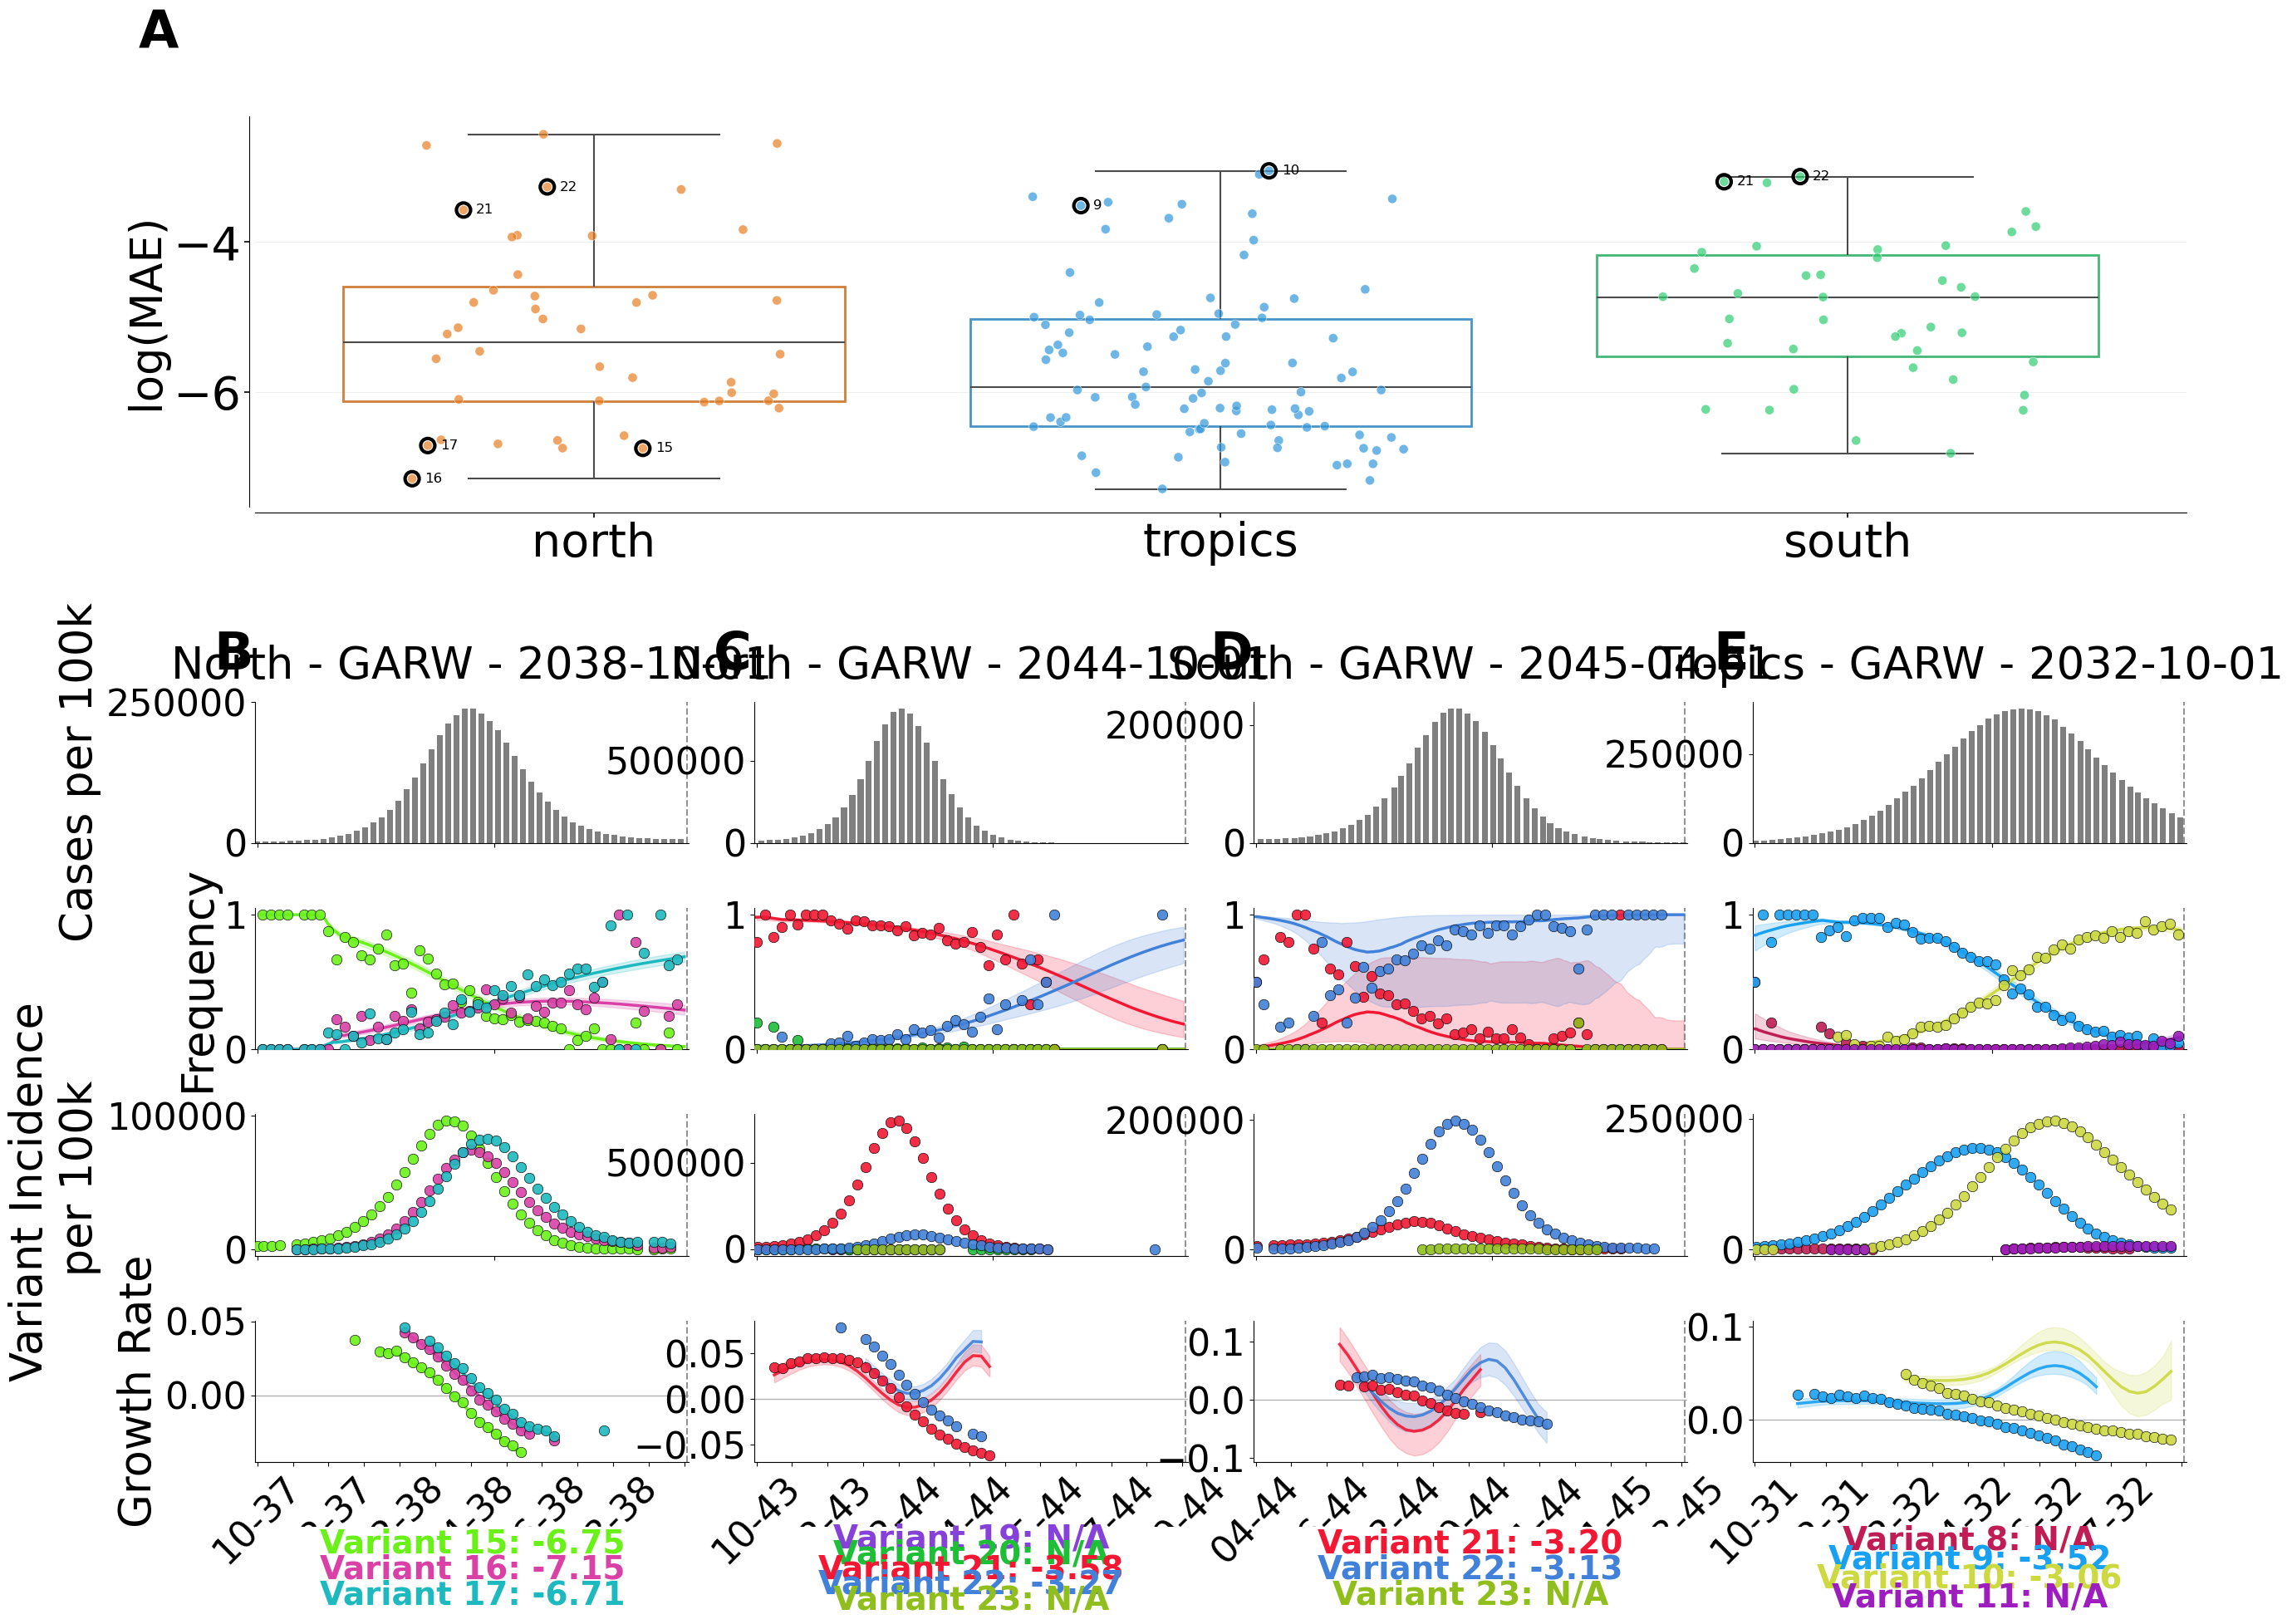

In [5]:
garw_save_path = '../../antigen-tex/reviews/round1/figures/figure4_combined_growth_rate_figure_garw'

# Example windows for the GARW figure (B = success, C-E = high-error), in panel order B, C, D, E.
window_specs = [
    {'pivot_date': '2038-10-01', 'location': 'north',   'model': 'GARW'},  # B: success (variants 15,16,17)
    {'pivot_date': '2044-10-01', 'location': 'north',   'model': 'GARW'},  # C (21,22)
    {'pivot_date': '2045-04-01', 'location': 'south',   'model': 'GARW'},  # D (21,22)
    {'pivot_date': '2032-10-01', 'location': 'tropics', 'model': 'GARW'},  # E (9,10)
]

plot_combined_growth_rate_figure(
    variant_growth_rate_errors_df, window_specs, build, color_map, deme_palette, model="GARW",
)
plt.savefig(f'{garw_save_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{garw_save_path}.png', dpi=300, bbox_inches='tight')
print(f"Saved {garw_save_path}.pdf")
plt.show()
